In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# **BBCC CIRA CIC DOHBRW 2020**

In [37]:
df = pd.read_csv("datasets\\bccc_cira_cic_dohbrw_2020.csv")

In [38]:
df.shape

(499106, 29)

In [39]:
"28 num var + 1 str var (response)"
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 499106 entries, 0 to 499105
Data columns (total 29 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   FlowBytesSent                           499106 non-null  int64  
 1   FlowSentRate                            499106 non-null  float64
 2   FlowBytesReceived                       499106 non-null  int64  
 3   FlowReceivedRate                        499106 non-null  float64
 4   PacketLengthVariance                    499106 non-null  float64
 5   PacketLengthStandardDeviation           499106 non-null  float64
 6   PacketLengthMean                        499106 non-null  float64
 7   PacketLengthMedian                      499106 non-null  float64
 8   PacketLengthMode                        499106 non-null  int64  
 9   PacketLengthSkewFromMedian              499106 non-null  float64
 10  PacketLengthSkewFromMode                499106 non-null

In [ ]:
df.isnull().sum()

FlowBytesSent                             0
FlowSentRate                              0
FlowBytesReceived                         0
FlowReceivedRate                          0
PacketLengthVariance                      0
PacketLengthStandardDeviation             0
PacketLengthMean                          0
PacketLengthMedian                        0
PacketLengthMode                          0
PacketLengthSkewFromMedian                0
PacketLengthSkewFromMode                  0
PacketLengthCoefficientofVariation        0
PacketTimeVariance                        0
PacketTimeStandardDeviation               0
PacketTimeMean                            0
PacketTimeMedian                          0
PacketTimeMode                            0
PacketTimeSkewFromMedian                  0
PacketTimeSkewFromMode                    0
PacketTimeCoefficientofVariation          0
ResponseTimeTimeVariance                  0
ResponseTimeTimeStandardDeviation         0
ResponseTimeTimeMean            

In [41]:
df.head(1).T

,0
FlowBytesSent,353
FlowSentRate,80.890348
FlowBytesReceived,393
FlowReceivedRate,90.056393
PacketLengthVariance,469.209877
PacketLengthStandardDeviation,21.661253
PacketLengthMean,82.888889
PacketLengthMedian,66.0
PacketLengthMode,66
PacketLengthSkewFromMedian,2.339046


In [42]:
df_num = df.select_dtypes(include=['number'])
df_cat = df.select_dtypes(exclude=['number'])

In [ ]:
df_cat['Label'].value_counts()

Label
Benign       249553
Malicious    249553
Name: count, dtype: int64

In [44]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
FlowBytesSent,499106.0,40200.925483,143961.655790,5.500000e+01,618.000000,1807.000000,5542.000000,8.015359e+06
FlowSentRate,499106.0,47339.147444,421275.128880,1.464903e+00,54.107811,364.096931,3810.259664,2.304348e+07
FlowBytesReceived,499106.0,42501.556227,139392.708614,5.400000e+01,476.000000,4827.000000,7888.000000,7.723184e+06
FlowReceivedRate,499106.0,31668.292337,256680.472304,1.576245e+00,141.812836,461.114551,4215.497773,7.600000e+06
PacketLengthVariance,499106.0,92635.849630,153493.758127,0.000000e+00,469.209877,18267.886503,141598.912222,1.578115e+06
PacketLengthStandardDeviation,499106.0,220.169083,210.141825,0.000000e+00,21.661253,135.142971,376.296309,1.256231e+03
PacketLengthMean,499106.0,173.159814,85.506490,5.600000e+01,92.000000,152.488283,228.758621,6.898000e+02
PacketLengthMedian,499106.0,95.472702,32.999740,5.400000e+01,76.000000,87.000000,105.000000,3.170000e+02
PacketLengthMode,499106.0,70.749953,14.830277,5.400000e+01,66.000000,68.000000,68.000000,5.530000e+02
PacketLengthSkewFromMedian,499106.0,0.442934,1.551998,-1.000000e+01,0.199848,0.986397,1.201609,2.932375e+00


In [35]:
df_num.corr()

,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,PacketLengthMedian,PacketLengthMode,PacketLengthSkewFromMedian,...,PacketTimeSkewFromMode,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation
FlowBytesSent,1.000000,-0.027537,0.815642,-0.029200,-0.125260,-0.121286,-0.038375,0.282036,-0.038400,0.042441,...,-0.003568,-0.202211,-0.040391,-0.055171,-0.054637,-0.045478,-0.032371,0.126485,0.037997,0.440981
FlowSentRate,-0.027537,1.000000,-0.030958,0.994330,-0.063464,-0.100646,-0.112469,-0.044428,-0.066774,-0.028486,...,-0.029392,-0.000057,-0.017295,-0.028733,-0.023904,-0.018816,-0.013394,-0.300554,-0.326855,-0.067198
FlowBytesReceived,0.815642,-0.030958,1.000000,-0.031073,-0.123848,-0.114174,-0.012396,0.370265,-0.036229,0.037382,...,0.019390,-0.208003,-0.043357,-0.063058,-0.060469,-0.049238,-0.034960,0.110233,0.045015,0.259427
FlowReceivedRate,-0.029200,0.994330,-0.031073,1.000000,-0.049494,-0.089524,-0.099818,-0.046553,-0.068310,-0.023304,...,-0.019066,-0.008451,-0.018952,-0.031398,-0.026166,-0.020591,-0.014698,-0.298879,-0.322588,-0.068752
PacketLengthVariance,-0.125260,-0.063464,-0.123848,-0.049494,1.000000,0.915403,0.845969,-0.216173,-0.164969,0.271415,...,-0.163580,0.279322,-0.019242,-0.047781,-0.096472,-0.096820,-0.071382,0.064658,0.231762,-0.044358
PacketLengthStandardDeviation,-0.121286,-0.100646,-0.114174,-0.089524,0.915403,1.000000,0.939291,-0.179838,-0.265381,0.415582,...,-0.263729,0.439985,-0.023060,-0.074818,-0.164639,-0.163849,-0.122509,0.143830,0.349109,-0.002290
PacketLengthMean,-0.038375,-0.112469,-0.012396,-0.099818,0.845969,0.939291,1.000000,0.022232,-0.254979,0.430143,...,-0.185222,0.352104,-0.037748,-0.097487,-0.203821,-0.200964,-0.150970,0.195822,0.359610,0.040978
PacketLengthMedian,0.282036,-0.044428,0.370265,-0.046553,-0.216173,-0.179838,0.022232,1.000000,0.148676,-0.169817,...,0.145118,-0.166792,-0.075071,-0.087071,-0.156990,-0.149564,-0.111617,0.140681,0.002990,0.168839
PacketLengthMode,-0.038400,-0.066774,-0.036229,-0.068310,-0.164969,-0.265381,-0.254979,0.148676,1.000000,-0.525916,...,0.000075,-0.101416,-0.083578,-0.086803,-0.089638,-0.071645,-0.063864,-0.196590,-0.246000,-0.127209
PacketLengthSkewFromMedian,0.042441,-0.028486,0.037382,-0.023304,0.271415,0.415582,0.430143,-0.169817,-0.525916,1.000000,...,-0.040562,0.156318,0.053003,0.055396,-0.277925,-0.242724,-0.366302,0.273067,0.336987,0.166317


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20464\3314545370.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='FlowBytesSent', ax=axes[2], palette=['green', 'red'])


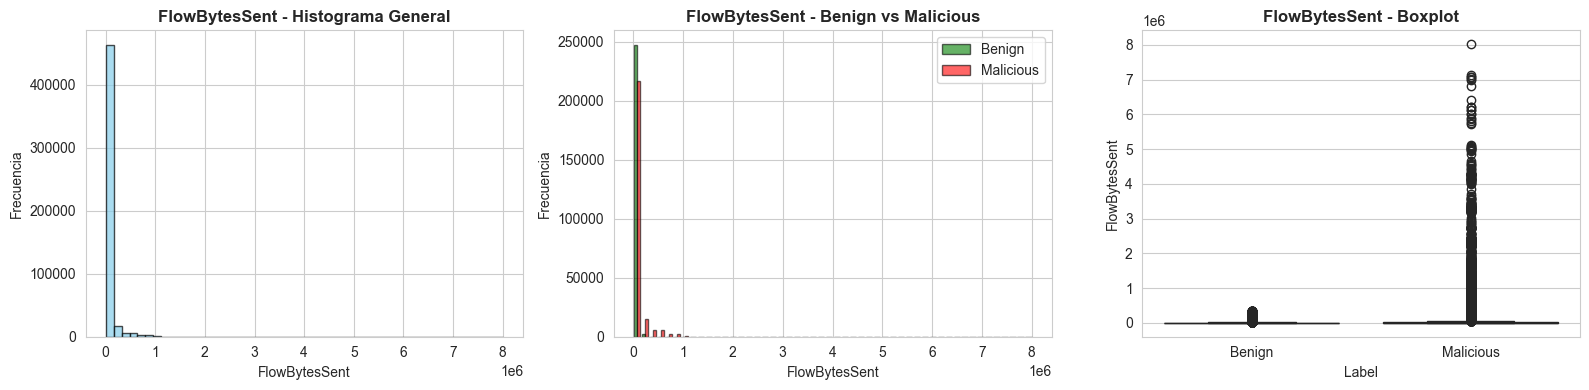

Benign - Mean: 10150.98, Std: 29947.29
Malicious - Mean: 70250.87, Std: 196842.97


In [46]:
"""FLOW FEATURES - FlowBytesSent"""
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma general
axes[0].hist(df['FlowBytesSent'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('FlowBytesSent - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('FlowBytesSent')
axes[0].set_ylabel('Frecuencia')

# Histograma por clase
df_benign = df[df['Label'] == 'Benign']['FlowBytesSent']
df_malicious = df[df['Label'] == 'Malicious']['FlowBytesSent']

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('FlowBytesSent - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FlowBytesSent')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Boxplot
sns.boxplot(data=df, x='Label', y='FlowBytesSent', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('FlowBytesSent - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('FlowBytesSent')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20464\2451612905.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='FlowSentRate', ax=axes[2], palette=['green', 'red'])


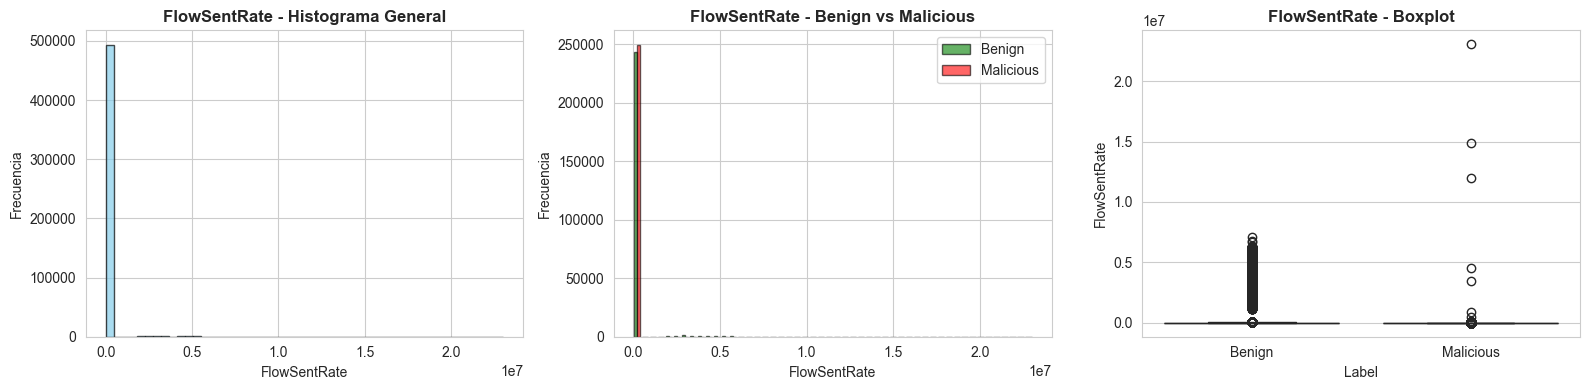

Benign - Mean: 93141.76, Std: 589083.17
Malicious - Mean: 1536.53, Std: 61085.32


In [47]:
"""FLOW FEATURES - FlowSentRate"""
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['FlowSentRate']
df_malicious = df[df['Label'] == 'Malicious']['FlowSentRate']

axes[0].hist(df['FlowSentRate'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('FlowSentRate - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('FlowSentRate')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('FlowSentRate - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FlowSentRate')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='FlowSentRate', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('FlowSentRate - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('FlowSentRate')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")